# Préparation des données

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Chargement des données brutes

In [98]:
DATA_PATH = "./datas/"

app_train    = pd.read_csv(DATA_PATH + "application_train.csv")
app_test     = pd.read_csv(DATA_PATH + "application_test.csv")
bureau       = pd.read_csv(DATA_PATH + "bureau.csv")
bureau_bal   = pd.read_csv(DATA_PATH + "bureau_balance.csv")
prev_app     = pd.read_csv(DATA_PATH + "previous_application.csv")
pos_cash     = pd.read_csv(DATA_PATH + "POS_CASH_balance.csv")
install      = pd.read_csv(DATA_PATH + "installments_payments.csv")
cc_bal       = pd.read_csv(DATA_PATH + "credit_card_balance.csv")

print("application_train :", app_train.shape)
print("application_test  :", app_test.shape)
print("bureau            :", bureau.shape)
print("bureau_bal            :", bureau_bal.shape)
print("previous_app      :", prev_app.shape)
print("pos_cash      :", pos_cash.shape)
print("install      :", install.shape)
print("cc_bal      :", cc_bal.shape)

application_train : (307511, 122)
application_test  : (48744, 121)
bureau            : (1716428, 17)
bureau_bal            : (27299925, 3)
previous_app      : (1670214, 37)
pos_cash      : (10001358, 8)
install      : (13605401, 8)
cc_bal      : (3840312, 23)


In [99]:
display(app_train.head(3))

print("\nTypes et valeurs manquantes")
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train)) * 100
missing_df = pd.DataFrame({
    'manquants': missing,
    'pct': missing_pct
}).sort_values('pct', ascending=False)
display(missing_df[missing_df['manquants'] > 0].head(10))

print("\nDistribution de la variable cible")
print(app_train['TARGET'].value_counts(normalize=True) * 100)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,...,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,...,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,-815.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000



Types et valeurs manquantes


,manquants,pct
COMMONAREA_AVG,214865,69.872
COMMONAREA_MODE,214865,69.872
COMMONAREA_MEDI,214865,69.872
NONLIVINGAPARTMENTS_MEDI,213514,69.433
NONLIVINGAPARTMENTS_MODE,213514,69.433
NONLIVINGAPARTMENTS_AVG,213514,69.433
FONDKAPREMONT_MODE,210295,68.386
LIVINGAPARTMENTS_AVG,210199,68.355
LIVINGAPARTMENTS_MEDI,210199,68.355
LIVINGAPARTMENTS_MODE,210199,68.355



Distribution de la variable cible
TARGET
0   91.927
1    8.073
Name: proportion, dtype: float64


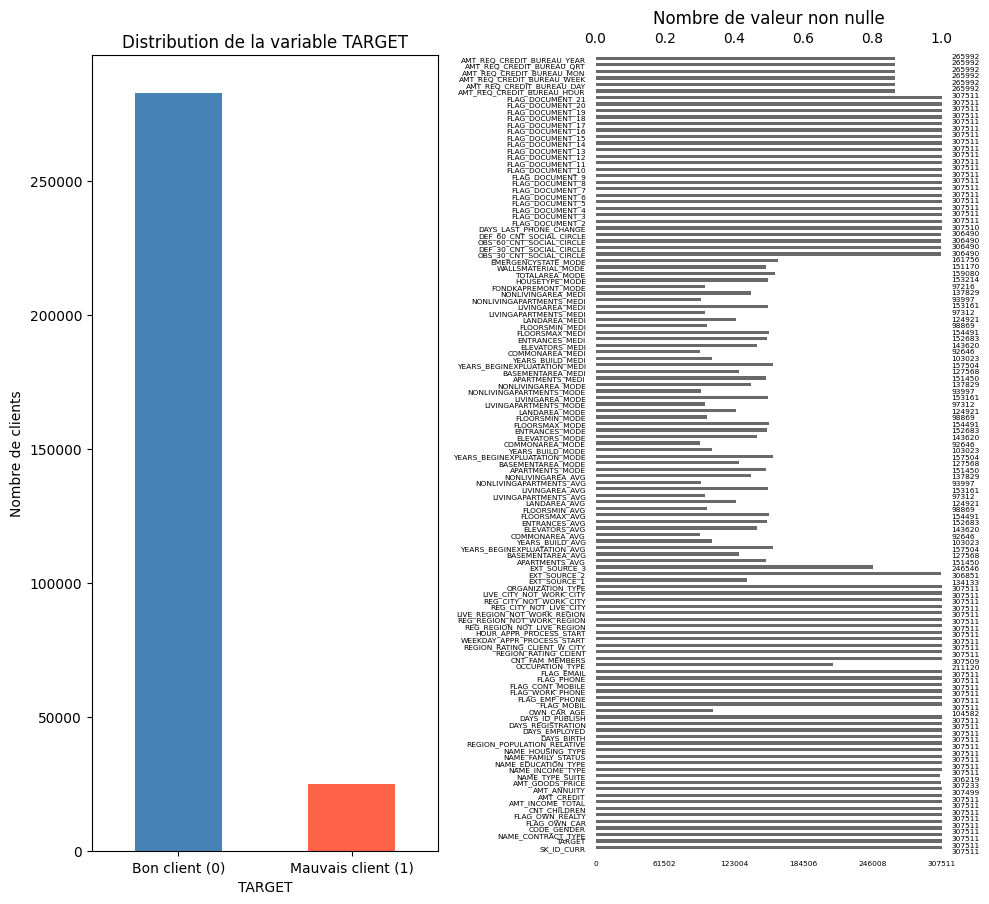

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution de la cible
app_train['TARGET'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title("Distribution de la variable TARGET")
axes[0].set_xticklabels(['Bon client (0)', 'Mauvais client (1)'], rotation=0)
axes[0].set_ylabel("Nombre de clients")

# Visualisation des valeurs manquantes
msno.bar(app_train, ax=axes[1], fontsize=5.4)
axes[1].set_title("Nombre de valeur non nulle")

fig = axes[1].figure
fig.set_size_inches(10, max(8, 0.075 * app_train.shape[1]))  # hauteur dynamique
fig.tight_layout()

plt.tight_layout()
plt.show()

In [101]:
# Calcul précis sur les 307 511 lignes complètes
missing_full = app_train.isnull().sum()
missing_pct  = (missing_full / len(app_train) * 100).round(2)

missing_df = pd.DataFrame({
    'n_manquants': missing_full,
    'pct_manquants': missing_pct
}).sort_values('pct_manquants', ascending=False)

# On ne garde que les colonnes qui ont au moins 1 valeur manquante
missing_df = missing_df[missing_df['n_manquants'] > 0]

print(f"Nombre de colonnes avec valeurs manquantes : {len(missing_df)}")
print(f"\nColonnes > 60% manquants")
print(missing_df[missing_df['pct_manquants'] > 60])
print(f"\nColonnes entre 30% et 60%")
print(missing_df[(missing_df['pct_manquants'] > 30) & (missing_df['pct_manquants'] <= 60)])
print(f"\n--- Colonnes entre 5% et 30%")
print(missing_df[(missing_df['pct_manquants'] > 5) & (missing_df['pct_manquants'] <= 30)])
print(f"\nColonnes < 5%")
print(missing_df[missing_df['pct_manquants'] <= 5])

Nombre de colonnes avec valeurs manquantes : 67

Colonnes > 60% manquants
                          n_manquants  pct_manquants
COMMONAREA_AVG                 214865         69.870
COMMONAREA_MODE                214865         69.870
COMMONAREA_MEDI                214865         69.870
NONLIVINGAPARTMENTS_MEDI       213514         69.430
NONLIVINGAPARTMENTS_MODE       213514         69.430
NONLIVINGAPARTMENTS_AVG        213514         69.430
FONDKAPREMONT_MODE             210295         68.390
LIVINGAPARTMENTS_AVG           210199         68.350
LIVINGAPARTMENTS_MEDI          210199         68.350
LIVINGAPARTMENTS_MODE          210199         68.350
FLOORSMIN_MODE                 208642         67.850
FLOORSMIN_AVG                  208642         67.850
FLOORSMIN_MEDI                 208642         67.850
YEARS_BUILD_AVG                204488         66.500
YEARS_BUILD_MODE               204488         66.500
YEARS_BUILD_MEDI               204488         66.500
OWN_CAR_AGE              

67 colonnes qui vont nécessiter des traitements différents :

1. 60% manquants (17 colonnes) : Suppression quasi-certaine. Imputer 2/3 d'un dataset c'est inventer des données. Exception : OWN_CAR_AGE où le manquant signifie "pas de voiture" (ce n'est pas un manquant aléatoire).
2. 30-60% manquants (33 colonnes) : On a deux sous-groupes : les caractéristiques du bâtiment (triplets AVG/MODE/MEDI redondants) et des variables utiles comme EXT_SOURCE_1 et OCCUPATION_TYPE. À examiner avant de décider.
3. 5-30% manquants (7 colonnes) : Les AMT_REQ_CREDIT_BUREAU_* : le manquant signifie probablement 0 requête, pas une valeur inconnue. EXT_SOURCE_3 : imputation.
4. 5% manquants : Imputation simple.

## 2. Nettoyage des données

In [102]:
# Traitement des valeurs abbérantes trouvé en analyse exploratoire
# 4 clients avec CODE_GENDER = 'XNA' : anomalie de saisie, à supprimer
n_avant = len(app_train)
app_train = app_train[app_train['CODE_GENDER'] != 'XNA'].reset_index(drop=True)
app_test  = app_test[app_test['CODE_GENDER'] != 'XNA'].reset_index(drop=True)
print(f"Lignes supprimées : {n_avant - len(app_train)}")
print(f"app_train : {app_train.shape}")

Lignes supprimées : 4
app_train : (307507, 122)


In [103]:
# Flag AVANT remplacement — l'EDA confirme que ces clients ont un taux de défaut distinct (5.4% vs 8.7%)
app_train['DAYS_EMPLOYED_ANOMALY'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)
app_test['DAYS_EMPLOYED_ANOMALY']  = (app_test['DAYS_EMPLOYED'] == 365243).astype(int)
print(f"Clients avec anomalie DAYS_EMPLOYED : {app_train['DAYS_EMPLOYED_ANOMALY'].sum():,}")
print(f"Taux de défaut si anomalie : {app_train.loc[app_train['DAYS_EMPLOYED_ANOMALY']==1,'TARGET'].mean():.3f}")
print(f"Taux de défaut si normal   : {app_train.loc[app_train['DAYS_EMPLOYED_ANOMALY']==0,'TARGET'].mean():.3f}")

# Remplacement par NaN
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)
app_test['DAYS_EMPLOYED']  = app_test['DAYS_EMPLOYED'].replace(365243, np.nan)

# Imputation par médiane des clients normaux uniquement (jamais sur les anomalies)
median_days_employed = app_train.loc[
    app_train['DAYS_EMPLOYED_ANOMALY'] == 0, 'DAYS_EMPLOYED'
].median()
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].fillna(median_days_employed)
app_test['DAYS_EMPLOYED']  = app_test['DAYS_EMPLOYED'].fillna(median_days_employed)

print(f"\nMédiane utilisée pour imputation : {median_days_employed:.0f}")
print(f"Valeurs manquantes DAYS_EMPLOYED : {app_train['DAYS_EMPLOYED'].isnull().sum()}")

Clients avec anomalie DAYS_EMPLOYED : 55,374
Taux de défaut si anomalie : 0.054
Taux de défaut si normal   : 0.087

Médiane utilisée pour imputation : -1648
Valeurs manquantes DAYS_EMPLOYED : 0


In [104]:
# L'EDA montre que l'absence d'historique est un signal en soi,
# pas simplement une valeur manquante à remplir par 0

clients_avec_bureau = bureau['SK_ID_CURR'].unique()
clients_avec_prev   = prev_app['SK_ID_CURR'].unique()

app_train['FLAG_NO_BUREAU'] = (~app_train['SK_ID_CURR'].isin(clients_avec_bureau)).astype(int)
app_test['FLAG_NO_BUREAU']  = (~app_test['SK_ID_CURR'].isin(clients_avec_bureau)).astype(int)

app_train['FLAG_NO_PREV']   = (~app_train['SK_ID_CURR'].isin(clients_avec_prev)).astype(int)
app_test['FLAG_NO_PREV']    = (~app_test['SK_ID_CURR'].isin(clients_avec_prev)).astype(int)

print(f"Clients sans historique bureau : {app_train['FLAG_NO_BUREAU'].sum():,} ({app_train['FLAG_NO_BUREAU'].mean()*100:.1f}%)")
print(f"Clients sans demande précédente : {app_train['FLAG_NO_PREV'].sum():,} ({app_train['FLAG_NO_PREV'].mean()*100:.1f}%)")

# Vérification taux de défaut
print(f"\nTaux défaut sans bureau : {app_train.loc[app_train['FLAG_NO_BUREAU']==1,'TARGET'].mean():.3f}")
print(f"Taux défaut avec bureau : {app_train.loc[app_train['FLAG_NO_BUREAU']==0,'TARGET'].mean():.3f}")
print(f"\nTaux défaut sans prev_app : {app_train.loc[app_train['FLAG_NO_PREV']==1,'TARGET'].mean():.3f}")
print(f"Taux défaut avec prev_app : {app_train.loc[app_train['FLAG_NO_PREV']==0,'TARGET'].mean():.3f}")

Clients sans historique bureau : 44,020 (14.3%)
Clients sans demande précédente : 16,454 (5.4%)

Taux défaut sans bureau : 0.101
Taux défaut avec bureau : 0.077

Taux défaut sans prev_app : 0.060
Taux défaut avec prev_app : 0.082


### correction des valeurs manquantes

In [105]:
cols_above_60 = [
    'COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG',
    'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI',
    'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI',
    'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE'
]

print("Corrélation avec TARGET (sur lignes non-nulles)\n")
for col in cols_above_60:
    subset = app_train[['TARGET', col]].dropna()
    dtype = app_train[col].dtype
    pct_missing = app_train[col].isnull().mean() * 100

    if dtype == 'object':
        # Colonne catégorielle : on affiche juste les modalités
        modalites = app_train[col].value_counts().index.tolist()
        print(f"{col:<35} | CATÉGORIELLE | {pct_missing:.1f}% manquants | modalités : {modalites}")
    else:
        corr = subset[col].corr(subset['TARGET'])
        print(f"{col:<35} | corr={corr:+.4f} | {pct_missing:.1f}% manquants")

Corrélation avec TARGET (sur lignes non-nulles)

COMMONAREA_AVG                      | corr=-0.0186 | 69.9% manquants
COMMONAREA_MODE                     | corr=-0.0163 | 69.9% manquants
COMMONAREA_MEDI                     | corr=-0.0186 | 69.9% manquants
NONLIVINGAPARTMENTS_MEDI            | corr=-0.0028 | 69.4% manquants
NONLIVINGAPARTMENTS_MODE            | corr=-0.0016 | 69.4% manquants
NONLIVINGAPARTMENTS_AVG             | corr=-0.0032 | 69.4% manquants
FONDKAPREMONT_MODE                  | CATÉGORIELLE | 68.4% manquants | modalités : ['reg oper account', 'reg oper spec account', 'not specified', 'org spec account']
LIVINGAPARTMENTS_AVG                | corr=-0.0250 | 68.4% manquants
LIVINGAPARTMENTS_MEDI               | corr=-0.0246 | 68.4% manquants
LIVINGAPARTMENTS_MODE               | corr=-0.0234 | 68.4% manquants
FLOORSMIN_MODE                      | corr=-0.0327 | 67.8% manquants
FLOORSMIN_AVG                       | corr=-0.0336 | 67.8% manquants
FLOORSMIN_MEDI            

Toutes les corrélations sont inférieures à 0.04 — un signal quasi nul. Ces colonnes n'apporteront rien au modèle même si on les imputait parfaitement. On peut donc les supprimer.

In [106]:
shape_avant = app_train.shape

app_train = app_train.drop(columns=cols_above_60)
app_test  = app_test.drop(columns=cols_above_60, errors='ignore')

print(f"Colonnes avant : {shape_avant[1]}")
print(f"Colonnes après : {app_train.shape[1]}")
print(f"Colonnes supprimées : {shape_avant[1] - app_train.shape[1]}")
print(f"Lignes conservées : {app_train.shape[0]} (inchangé)")

Colonnes avant : 125
Colonnes après : 108
Colonnes supprimées : 17
Lignes conservées : 307507 (inchangé)


In [107]:
cols_30_60 = [
    'LANDAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MODE',
    'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG',
    'EXT_SOURCE_1',
    'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI',
    'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE',
    'WALLSMATERIAL_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE',
    'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG',
    'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
    'HOUSETYPE_MODE', 'FLOORSMAX_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI',
    'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG',
    'TOTALAREA_MODE', 'EMERGENCYSTATE_MODE', 'OCCUPATION_TYPE'
]

print("Corrélation avec TARGET (30-60% manquants)\n")
for col in cols_30_60:
    subset = app_train[['TARGET', col]].dropna()
    pct_missing = app_train[col].isnull().mean() * 100
    dtype = app_train[col].dtype

    if dtype == 'object':
        modalites = app_train[col].dropna().unique().tolist()
        print(f"{col:<40} | CATÉGORIELLE | {pct_missing:.1f}% manquants | {len(modalites)} modalités : {modalites[:5]}")
    else:
        corr = subset[col].corr(subset['TARGET'])
        print(f"{col:<40} | corr={corr:+.4f} | {pct_missing:.1f}% manquants")

Corrélation avec TARGET (30-60% manquants)

LANDAREA_MEDI                            | corr=-0.0113 | 59.4% manquants
LANDAREA_AVG                             | corr=-0.0109 | 59.4% manquants
LANDAREA_MODE                            | corr=-0.0102 | 59.4% manquants
BASEMENTAREA_MODE                        | corr=-0.0200 | 58.5% manquants
BASEMENTAREA_MEDI                        | corr=-0.0221 | 58.5% manquants
BASEMENTAREA_AVG                         | corr=-0.0227 | 58.5% manquants
EXT_SOURCE_1                             | corr=-0.1553 | 56.4% manquants
NONLIVINGAREA_MODE                       | corr=-0.0127 | 55.2% manquants
NONLIVINGAREA_AVG                        | corr=-0.0136 | 55.2% manquants
NONLIVINGAREA_MEDI                       | corr=-0.0133 | 55.2% manquants
ELEVATORS_AVG                            | corr=-0.0342 | 53.3% manquants
ELEVATORS_MEDI                           | corr=-0.0339 | 53.3% manquants
ELEVATORS_MODE                           | corr=-0.0321 | 53.3% manq

1. EXT_SOURCE_1 se détache complètement avec -0.155 : c'est presque 4* plus corrélé que n'importe quelle autre colonne du groupe. Elle est indispensable malgré les 56% de manquants. On l'impute.
2. OCCUPATION_TYPE : 18 modalités, 31% de manquants : ici ça veut dire "profession inconnue". On crée une catégorie "unknown".
3. EMERGENCYSTATE_MODE : binaire (Yes/No), 47% de manquants : corrélation quasi nulle. Peu utile mais facile à gérer.
4. Tout le reste : triplets AVG/MODE/MEDI, corrélations toutes < 0.05 en valeur absolue, >48% de manquants. Aucun intérêt à imputer autant de données pour un signal aussi faible. → Suppression.

In [108]:
cols_to_drop_30_60 = [
    'LANDAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MODE',
    'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG',
    'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI',
    'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE',
    'WALLSMATERIAL_MODE',
    'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE',
    'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG',
    'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
    'HOUSETYPE_MODE',
    'FLOORSMAX_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI',
    'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG',
    'TOTALAREA_MODE',
]

shape_avant = app_train.shape
app_train = app_train.drop(columns=cols_to_drop_30_60)
app_test  = app_test.drop(columns=cols_to_drop_30_60, errors='ignore')

print(f"Colonnes avant : {shape_avant[1]}")
print(f"Colonnes après : {app_train.shape[1]}")
print(f"Colonnes supprimées : {shape_avant[1] - app_train.shape[1]}")

# Vérification que les 3 colonnes à conserver sont bien là
for col in ['EXT_SOURCE_1', 'OCCUPATION_TYPE', 'EMERGENCYSTATE_MODE']:
    print(f"  ✓ {col} présent : {col in app_train.columns}")

Colonnes avant : 108
Colonnes après : 78
Colonnes supprimées : 30
  ✓ EXT_SOURCE_1 présent : True
  ✓ OCCUPATION_TYPE présent : True
  ✓ EMERGENCYSTATE_MODE présent : True


In [109]:
# EXT_SOURCE_1 : Flag binaire AVANT imputation
app_train['EXT_SOURCE_1_MISSING'] = app_train['EXT_SOURCE_1'].isnull().astype(int)
app_test['EXT_SOURCE_1_MISSING']  = app_test['EXT_SOURCE_1'].isnull().astype(int)

# Médiane calculée sur le train uniquement (jamais sur le test)
median_ext1 = app_train['EXT_SOURCE_1'].median()
app_train['EXT_SOURCE_1'] = app_train['EXT_SOURCE_1'].fillna(median_ext1)
app_test['EXT_SOURCE_1']  = app_test['EXT_SOURCE_1'].fillna(median_ext1)

# OCCUPATION_TYPE
app_train['OCCUPATION_TYPE'] = app_train['OCCUPATION_TYPE'].fillna('Unknown')
app_test['OCCUPATION_TYPE']  = app_test['OCCUPATION_TYPE'].fillna('Unknown')

# EMERGENCYSTATE_MODE
mode_emergency = app_train['EMERGENCYSTATE_MODE'].mode()[0]
app_train['EMERGENCYSTATE_MODE'] = app_train['EMERGENCYSTATE_MODE'].fillna(mode_emergency)
app_test['EMERGENCYSTATE_MODE']  = app_test['EMERGENCYSTATE_MODE'].fillna(mode_emergency)

# Vérification
cols_check = ['EXT_SOURCE_1', 'EXT_SOURCE_1_MISSING', 'OCCUPATION_TYPE', 'EMERGENCYSTATE_MODE']
print("=== Vérification après imputation ===\n")
for col in cols_check:
    n_missing = app_train[col].isnull().sum()
    print(f"{col:<30} | manquants restants : {n_missing}")

print(f"\nMédiane EXT_SOURCE_1 utilisée       : {median_ext1:.4f}")
print(f"Mode EMERGENCYSTATE_MODE utilisé    : {mode_emergency}")
print(f"Modalités OCCUPATION_TYPE           : {sorted(app_train['OCCUPATION_TYPE'].unique())}")

=== Vérification après imputation ===

EXT_SOURCE_1                   | manquants restants : 0
EXT_SOURCE_1_MISSING           | manquants restants : 0
OCCUPATION_TYPE                | manquants restants : 0
EMERGENCYSTATE_MODE            | manquants restants : 0

Médiane EXT_SOURCE_1 utilisée       : 0.5060
Mode EMERGENCYSTATE_MODE utilisé    : No
Modalités OCCUPATION_TYPE           : ['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Unknown', 'Waiters/barmen staff']


In [110]:
cols_5_30 = [
    'EXT_SOURCE_3',
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
]

print("=== Analyse du groupe 5-30% manquants ===\n")
for col in cols_5_30:
    subset = app_train[['TARGET', col]].dropna()
    corr = subset[col].corr(subset['TARGET'])
    pct_missing = app_train[col].isnull().mean() * 100
    print(f"{col:<35} | corr={corr:+.4f} | {pct_missing:.1f}% manquants")

# Hypothèse spécifique sur AMT_REQ_CREDIT_BUREAU_* :
# les manquants et les zéros sont-ils liés au même profil de client ?
print("\n=== Distribution des valeurs non-nulles (AMT_REQ_CREDIT_BUREAU_YEAR) ===")
print(app_train['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts().head(10))

print("\n=== Taux de défaut : manquants vs non-manquants (AMT_REQ_CREDIT_BUREAU_YEAR) ===")
mask_missing = app_train['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull()
print(f"Taux défaut si MANQUANT     : {app_train.loc[mask_missing, 'TARGET'].mean():.4f}")
print(f"Taux défaut si NON-MANQUANT : {app_train.loc[~mask_missing, 'TARGET'].mean():.4f}")

=== Analyse du groupe 5-30% manquants ===

EXT_SOURCE_3                        | corr=-0.1789 | 19.8% manquants
AMT_REQ_CREDIT_BUREAU_HOUR          | corr=+0.0009 | 13.5% manquants
AMT_REQ_CREDIT_BUREAU_DAY           | corr=+0.0027 | 13.5% manquants
AMT_REQ_CREDIT_BUREAU_WEEK          | corr=+0.0008 | 13.5% manquants
AMT_REQ_CREDIT_BUREAU_MON           | corr=-0.0125 | 13.5% manquants
AMT_REQ_CREDIT_BUREAU_QRT           | corr=-0.0020 | 13.5% manquants
AMT_REQ_CREDIT_BUREAU_YEAR          | corr=+0.0199 | 13.5% manquants

=== Distribution des valeurs non-nulles (AMT_REQ_CREDIT_BUREAU_YEAR) ===
AMT_REQ_CREDIT_BUREAU_YEAR
0.000    71801
1.000    63404
2.000    50192
3.000    33627
4.000    20713
5.000    12052
6.000     6966
7.000     3869
8.000     2127
9.000     1096
Name: count, dtype: int64

=== Taux de défaut : manquants vs non-manquants (AMT_REQ_CREDIT_BUREAU_YEAR) ===
Taux défaut si MANQUANT     : 0.1034
Taux défaut si NON-MANQUANT : 0.0772


In [111]:
print(app_train.loc[mask_missing, 'TARGET'].sum()/len(app_train))
print(app_train.loc[~mask_missing, 'TARGET'].sum()/len(app_train))

0.01395740584767176
0.06677246371627313


1. EXT_SOURCE_3 : corr=-0.179, la plus prédictive de tout le dataset avec EXT_SOURCE_2. Même traitement qu'EXT_SOURCE_1 — médiane + flag manquant.
2. AMT_REQ_CREDIT_BUREAU_* : corrélations toutes proches de 0, les valeurs elles-mêmes n'apportent presque rien. Mais le taux de défaut des clients manquants (10.3%) est significativement plus élevé que celui des non-manquants (7.7%). Le fait d'être manquant est plus informatif que la valeur elle-même. On crée un seul flag binaire partagé (les 6 colonnes ont exactement le même 13.5% — ce sont les mêmes lignes), puis on remplit avec 0 (interprétation naturelle : pas de requête enregistrée).

In [112]:
# --- EXT_SOURCE_3 ---
app_train['EXT_SOURCE_3_MISSING'] = app_train['EXT_SOURCE_3'].isnull().astype(int)
app_test['EXT_SOURCE_3_MISSING']  = app_test['EXT_SOURCE_3'].isnull().astype(int)

median_ext3 = app_train['EXT_SOURCE_3'].median()
app_train['EXT_SOURCE_3'] = app_train['EXT_SOURCE_3'].fillna(median_ext3)
app_test['EXT_SOURCE_3']  = app_test['EXT_SOURCE_3'].fillna(median_ext3)

# --- AMT_REQ_CREDIT_BUREAU_* ---
# Un seul flag partagé (mêmes lignes manquantes pour les 6 colonnes)
cols_req = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
]

# Vérification que ce sont bien exactement les mêmes lignes manquantes
missing_counts = app_train[cols_req].isnull().sum()
print("=== Nb manquants par colonne AMT_REQ (doit être identique) ===")
print(missing_counts)

# Flag unique
app_train['AMT_REQ_CREDIT_BUREAU_MISSING'] = app_train[cols_req[0]].isnull().astype(int)
app_test['AMT_REQ_CREDIT_BUREAU_MISSING']  = app_test[cols_req[0]].isnull().astype(int)

# Remplissage par 0
app_train[cols_req] = app_train[cols_req].fillna(0)
app_test[cols_req]  = app_test[cols_req].fillna(0)

# Vérification finale
print("\n=== Vérification après imputation ===")
cols_check = ['EXT_SOURCE_3', 'EXT_SOURCE_3_MISSING',
              'AMT_REQ_CREDIT_BUREAU_MISSING'] + cols_req
for col in cols_check:
    print(f"{col:<35} | manquants : {app_train[col].isnull().sum()}")

print(f"\nMédiane EXT_SOURCE_3 utilisée : {median_ext3:.4f}")

=== Nb manquants par colonne AMT_REQ (doit être identique) ===
AMT_REQ_CREDIT_BUREAU_HOUR    41519
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
dtype: int64

=== Vérification après imputation ===
EXT_SOURCE_3                        | manquants : 0
EXT_SOURCE_3_MISSING                | manquants : 0
AMT_REQ_CREDIT_BUREAU_MISSING       | manquants : 0
AMT_REQ_CREDIT_BUREAU_HOUR          | manquants : 0
AMT_REQ_CREDIT_BUREAU_DAY           | manquants : 0
AMT_REQ_CREDIT_BUREAU_WEEK          | manquants : 0
AMT_REQ_CREDIT_BUREAU_MON           | manquants : 0
AMT_REQ_CREDIT_BUREAU_QRT           | manquants : 0
AMT_REQ_CREDIT_BUREAU_YEAR          | manquants : 0

Médiane EXT_SOURCE_3 utilisée : 0.5353


In [113]:
cols_under_5 = [
    'NAME_TYPE_SUITE',
    'DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE',
    'EXT_SOURCE_2',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'CNT_FAM_MEMBERS',
    'DAYS_LAST_PHONE_CHANGE',
]

print("=== Analyse du groupe <5% manquants ===\n")
for col in cols_under_5:
    pct_missing = app_train[col].isnull().mean() * 100
    dtype = app_train[col].dtype

    if dtype == 'object':
        modalites = app_train[col].dropna().unique().tolist()
        mode_val = app_train[col].mode()[0]
        print(f"{col:<35} | CATÉGORIELLE | {pct_missing:.2f}% manquants | mode='{mode_val}' | {len(modalites)} modalités")
    else:
        subset = app_train[['TARGET', col]].dropna()
        corr = subset[col].corr(subset['TARGET'])
        print(f"{col:<35} | corr={corr:+.4f} | {pct_missing:.2f}% manquants")

=== Analyse du groupe <5% manquants ===

NAME_TYPE_SUITE                     | CATÉGORIELLE | 0.42% manquants | mode='Unaccompanied' | 7 modalités
DEF_60_CNT_SOCIAL_CIRCLE            | corr=+0.0313 | 0.33% manquants
OBS_60_CNT_SOCIAL_CIRCLE            | corr=+0.0090 | 0.33% manquants
DEF_30_CNT_SOCIAL_CIRCLE            | corr=+0.0323 | 0.33% manquants
OBS_30_CNT_SOCIAL_CIRCLE            | corr=+0.0091 | 0.33% manquants
EXT_SOURCE_2                        | corr=-0.1605 | 0.21% manquants
AMT_GOODS_PRICE                     | corr=-0.0396 | 0.09% manquants
AMT_ANNUITY                         | corr=-0.0128 | 0.00% manquants
CNT_FAM_MEMBERS                     | corr=+0.0093 | 0.00% manquants
DAYS_LAST_PHONE_CHANGE              | corr=+0.0552 | 0.00% manquants


1. EXT_SOURCE_2 : corr=-0.160, très prédictive — mais seulement 0.21% de manquants, donc pas besoin de flag (trop peu de lignes concernées pour que le flag soit informatif). Médiane.
2. NAME_TYPE_SUITE : catégorielle, 0.42% → mode ('Unaccompanied').
3. Toutes les autres numériques : corrélations faibles à modérées, <0.5% de manquants → médiane, sans flag.

In [114]:
# Médiane calculée sur train uniquement
cols_numeric_under5 = [
    'DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE',
    'EXT_SOURCE_2', 'AMT_GOODS_PRICE', 'AMT_ANNUITY',
    'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE',
]

medians = app_train[cols_numeric_under5].median()

app_train[cols_numeric_under5] = app_train[cols_numeric_under5].fillna(medians)
app_test[cols_numeric_under5]  = app_test[cols_numeric_under5].fillna(medians)

# NAME_TYPE_SUITE : mode
mode_suite = app_train['NAME_TYPE_SUITE'].mode()[0]
app_train['NAME_TYPE_SUITE'] = app_train['NAME_TYPE_SUITE'].fillna(mode_suite)
app_test['NAME_TYPE_SUITE']  = app_test['NAME_TYPE_SUITE'].fillna(mode_suite)

# Vérification globale : plus aucun manquant dans app_train
total_missing = app_train.isnull().sum().sum()
print(f"Total valeurs manquantes restantes dans app_train : {total_missing}")

if total_missing == 0:
    print("✓ Dataset entièrement nettoyé.")
else:
    # Identifier les colonnes restantes si besoin
    remaining = app_train.isnull().sum()
    print("\nColonnes avec manquants restants :")
    print(remaining[remaining > 0])

Total valeurs manquantes restantes dans app_train : 0
✓ Dataset entièrement nettoyé.


In [115]:
print("=== Bilan après nettoyage ===\n")
print(f"app_train : {app_train.shape}")
print(f"app_test  : {app_test.shape}")

n_num = app_train.select_dtypes('number').shape[1]
n_cat = app_train.select_dtypes('object').shape[1]
print(f"\nColonnes numériques : {n_num}")
print(f"Colonnes catégorielles : {n_cat}")

print("\n=== Colonnes catégorielles restantes ===")
cat_cols = app_train.select_dtypes('object').columns.tolist()
for col in cat_cols:
    n_mod = app_train[col].nunique()
    print(f"  {col:<30} | {n_mod} modalités : {app_train[col].unique().tolist()[:5]}")

print("\n=== Aperçu des corrélations numériques avec TARGET (top 15) ===")
corr_target = app_train.select_dtypes('number').corr()['TARGET'].drop('TARGET')
corr_sorted = corr_target.abs().sort_values(ascending=False)
print(corr_sorted.head(15).to_string())

=== Bilan après nettoyage ===

app_train : (307507, 81)
app_test  : (48744, 80)

Colonnes numériques : 68
Colonnes catégorielles : 13

=== Colonnes catégorielles restantes ===
  NAME_CONTRACT_TYPE             | 2 modalités : ['Cash loans', 'Revolving loans']
  CODE_GENDER                    | 2 modalités : ['M', 'F']
  FLAG_OWN_CAR                   | 2 modalités : ['N', 'Y']
  FLAG_OWN_REALTY                | 2 modalités : ['Y', 'N']
  NAME_TYPE_SUITE                | 7 modalités : ['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Other_A']
  NAME_INCOME_TYPE               | 8 modalités : ['Working', 'State servant', 'Commercial associate', 'Pensioner', 'Unemployed']
  NAME_EDUCATION_TYPE            | 5 modalités : ['Secondary / secondary special', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Academic degree']
  NAME_FAMILY_STATUS             | 6 modalités : ['Single / not married', 'Married', 'Civil marriage', 'Widow', 'Separated']
  NAME_HOUSING_TYPE       

## 3. Aggrégation des fichiers

### *bureau.csv* et *bureau_balance.csv*

In [116]:
print("=== bureau.csv ===")
print(f"Shape : {bureau.shape}")
print(f"Clé de jointure avec app_train : SK_ID_CURR")
print(f"Clé de jointure avec bureau_balance : SK_ID_BUREAU")
print(f"\nColonnes : {bureau.columns.tolist()}")
print(f"\nValeurs manquantes (%) :")
missing_b = (bureau.isnull().sum() / len(bureau) * 100).round(2)
print(missing_b[missing_b > 0].sort_values(ascending=False))

print("\n=== bureau_balance.csv ===")
print(f"Shape : {bureau_bal.shape}")
print(f"\nColonnes : {bureau_bal.columns.tolist()}")
print(f"\nDistribution STATUS :")
print(bureau_bal['STATUS'].value_counts())
print(f"\nValeurs manquantes : {bureau_bal.isnull().sum().sum()}")

=== bureau.csv ===
Shape : (1716428, 17)
Clé de jointure avec app_train : SK_ID_CURR
Clé de jointure avec bureau_balance : SK_ID_BUREAU

Colonnes : ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

Valeurs manquantes (%) :
AMT_ANNUITY              71.470
AMT_CREDIT_MAX_OVERDUE   65.510
DAYS_ENDDATE_FACT        36.920
AMT_CREDIT_SUM_LIMIT     34.480
AMT_CREDIT_SUM_DEBT      15.010
DAYS_CREDIT_ENDDATE       6.150
dtype: float64

=== bureau_balance.csv ===
Shape : (27299925, 3)

Colonnes : ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

Distribution STATUS :
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

Vale

- `bureau.csv` : un crédit passé par ligne. Un client peut en avoir plusieurs. On va devoir agréger par SK_ID_CURR pour revenir à une ligne par client.
- `bureau_balance.csv` : un snapshot mensuel par crédit bureau. Le STATUS encode le retard de paiement — C=clôturé, 0=aucun retard, 1 à 5=retard croissant en jours, X=inconnu. On agrège d'abord par SK_ID_BUREAU, puis on merge dans bureau.

In [117]:
print("=== CREDIT_ACTIVE (crédit encore ouvert ou clôturé ?) ===")
print(bureau['CREDIT_ACTIVE'].value_counts())

print("\n=== CREDIT_TYPE (type de crédit) ===")
print(bureau['CREDIT_TYPE'].value_counts())

print("\n=== AMT_CREDIT_MAX_OVERDUE (65% manquants — lié à CREDIT_ACTIVE ?) ===")
# Hypothesis : manquant = jamais eu de retard (donc pas de max overdue enregistré)
mask = bureau['AMT_CREDIT_MAX_OVERDUE'].isnull()
print(f"Taux crédits actifs si MAX_OVERDUE manquant     : "
      f"{(bureau.loc[mask, 'CREDIT_ACTIVE'] == 'Active').mean():.3f}")
print(f"Taux crédits actifs si MAX_OVERDUE non-manquant : "
      f"{(bureau.loc[~mask, 'CREDIT_ACTIVE'] == 'Active').mean():.3f}")

print("\n=== DAYS_ENDDATE_FACT (manquant = crédit encore actif ?) ===")
mask2 = bureau['DAYS_ENDDATE_FACT'].isnull()
print(f"Taux crédits actifs si ENDDATE_FACT manquant     : "
      f"{(bureau.loc[mask2, 'CREDIT_ACTIVE'] == 'Active').mean():.3f}")
print(f"Taux crédits actifs si ENDDATE_FACT non-manquant : "
      f"{(bureau.loc[~mask2, 'CREDIT_ACTIVE'] == 'Active').mean():.3f}")

print("\n=== AMT_CREDIT_SUM_DEBT (15% manquants) ===")
print(f"Médiane : {bureau['AMT_CREDIT_SUM_DEBT'].median():.0f}")
print(f"Valeurs à 0 : {(bureau['AMT_CREDIT_SUM_DEBT'] == 0).sum()}")

=== CREDIT_ACTIVE (crédit encore ouvert ou clôturé ?) ===
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

=== CREDIT_TYPE (type de crédit) ===
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                        

1. AMT_CREDIT_MAX_OVERDUE : l'hypothèse est infirmée — les manquants sont répartis de façon identique entre crédits actifs et clôturés (36.7% vs 36.9%). C'est du manquant aléatoire, pas structurel. Avec 65% de manquants sans logique explicable → on la supprime.
2. DAYS_ENDDATE_FACT : hypothèse confirmée à 99.2% — manquant = crédit encore actif. C'est un manquant structurel et logique. On n'en a pas besoin car CREDIT_ACTIVE encode déjà cette information directement.
3. AMT_CREDIT_SUM_DEBT : médiane = 0, 60% des valeurs sont déjà à 0. Les 15% manquants correspondent très probablement à des crédits clôturés sans dette → on remplit par 0.
4. CREDIT_TYPE : 15 modalités mais 2 dominent à 96% (consumer credit + credit card). Les 13 autres sont du bruit → on regroupe en "Other".

In [118]:
# === ETAPE 1 : bureau_balance → une ligne par SK_ID_BUREAU ===
# STATUS encode le comportement de paiement mensuel :
# C=clôturé, 0=aucun retard, 1-5=retard croissant, X=inconnu
# On veut capturer : combien de mois avec retard, et la sévérité max

bureau_bal['DPD'] = bureau_bal['STATUS'].isin(['1','2','3','4','5']).astype(int)
bureau_bal['DPD_SEVERE'] = bureau_bal['STATUS'].isin(['3','4','5']).astype(int)

bb_agg = bureau_bal.groupby('SK_ID_BUREAU').agg(
    BB_COUNT=('MONTHS_BALANCE', 'count'),        # durée historique en mois
    BB_DPD_COUNT=('DPD', 'sum'),                 # nb mois avec retard
    BB_DPD_SEVERE_COUNT=('DPD_SEVERE', 'sum'),   # nb mois avec retard sévère (>90j)
).reset_index()

print(f"bb_agg shape : {bb_agg.shape}")
print(bb_agg.head(3))

bb_agg shape : (817395, 4)
   SK_ID_BUREAU  BB_COUNT  BB_DPD_COUNT  BB_DPD_SEVERE_COUNT
0       5001709        97             0                    0
1       5001710        83             0                    0
2       5001711         4             0                    0


In [119]:
# === ETAPE 2 : Préparation bureau.csv avant agrégation ===

# Suppression des colonnes injustifiables
bureau = bureau.drop(columns=[
    'AMT_CREDIT_MAX_OVERDUE',   # 65% manquants, répartition aléatoire
    'DAYS_ENDDATE_FACT',        # redondant avec CREDIT_ACTIVE
    'CREDIT_CURRENCY',          # quasi-constante (>99% 'currency 1')
])

# Remplissage AMT_CREDIT_SUM_DEBT : 0 si manquant (crédit clôturé sans dette)
bureau['AMT_CREDIT_SUM_DEBT'] = bureau['AMT_CREDIT_SUM_DEBT'].fillna(0)

# Remplissage AMT_CREDIT_SUM_LIMIT : 0 si manquant (pas de limite enregistrée)
bureau['AMT_CREDIT_SUM_LIMIT'] = bureau['AMT_CREDIT_SUM_LIMIT'].fillna(0)

# DAYS_CREDIT_ENDDATE : date de fin prévue, 6% manquants → médiane
bureau['DAYS_CREDIT_ENDDATE'] = bureau['DAYS_CREDIT_ENDDATE'].fillna(
    bureau['DAYS_CREDIT_ENDDATE'].median()
)

# Simplification CREDIT_TYPE : garder top 2, regrouper le reste
top_types = ['Consumer credit', 'Credit card']
bureau['CREDIT_TYPE'] = bureau['CREDIT_TYPE'].apply(
    lambda x: x if x in top_types else 'Other'
)

# Flag crédit actif (plus lisible pour les agrégations)
bureau['IS_ACTIVE'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)

# Merge avec bureau_balance agrégé
bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

# Les crédits sans entrée dans bureau_balance → 0 mois d'historique
bureau[['BB_COUNT','BB_DPD_COUNT','BB_DPD_SEVERE_COUNT']] = \
    bureau[['BB_COUNT','BB_DPD_COUNT','BB_DPD_SEVERE_COUNT']].fillna(0)

print(f"\nbureau après préparation : {bureau.shape}")
print(f"Valeurs manquantes restantes :\n"
      f"{bureau.isnull().sum()[bureau.isnull().sum() > 0]}")


bureau après préparation : (1716428, 18)
Valeurs manquantes restantes :
AMT_CREDIT_SUM         13
AMT_ANNUITY       1226791
dtype: int64


Deux cas restants simples à traiter avant l'agrégation :
1. AMT_CREDIT_SUM : 13 lignes manquantes sur 1.7M — médiane, sans débat.
2. AMT_ANNUITY : 71% de manquants — on l'avait vu dans l'inspection initiale mais on ne l'avait pas supprimée. Elle ne peut pas être agrégée utilement avec autant de trous → suppression.

In [120]:
# Nettoyage des 2 restants
bureau['AMT_CREDIT_SUM'] = bureau['AMT_CREDIT_SUM'].fillna(
    bureau['AMT_CREDIT_SUM'].median()
)
bureau = bureau.drop(columns=['AMT_ANNUITY'])

print(f"Valeurs manquantes restantes : {bureau.isnull().sum().sum()}")

# === Agrégation globale par SK_ID_CURR ===
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT=('IS_ACTIVE', 'sum'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_SUM_TOTAL=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AMT_CREDIT_SUM_LIMIT_TOTAL=('AMT_CREDIT_SUM_LIMIT', 'sum'),
    BUREAU_BB_DPD_COUNT_TOTAL=('BB_DPD_COUNT', 'sum'),
    BUREAU_BB_DPD_SEVERE_COUNT_TOTAL=('BB_DPD_SEVERE_COUNT', 'sum'),
    BUREAU_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
).reset_index()

bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL'] /
    bureau_agg['BUREAU_AMT_CREDIT_SUM_TOTAL'].replace(0, np.nan)
).fillna(0)

# === Agrégation crédits ACTIFS uniquement ===
# L'EDA confirme que crédits actifs et clôturés ont des profils distincts
active = bureau[bureau['IS_ACTIVE'] == 1]
active_agg = active.groupby('SK_ID_CURR').agg(
    ACTIVE_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    ACTIVE_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    ACTIVE_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    ACTIVE_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    ACTIVE_AMT_CREDIT_SUM_TOTAL=('AMT_CREDIT_SUM', 'sum'),
    ACTIVE_AMT_CREDIT_SUM_DEBT_TOTAL=('AMT_CREDIT_SUM_DEBT', 'sum'),
    ACTIVE_BB_DPD_COUNT_TOTAL=('BB_DPD_COUNT', 'sum'),
).reset_index()

# === Agrégation crédits CLÔTURÉS uniquement ===
closed = bureau[bureau['IS_ACTIVE'] == 0]
closed_agg = closed.groupby('SK_ID_CURR').agg(
    CLOSED_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    CLOSED_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    CLOSED_AMT_CREDIT_SUM_TOTAL=('AMT_CREDIT_SUM', 'sum'),
    CLOSED_AMT_CREDIT_SUM_DEBT_TOTAL=('AMT_CREDIT_SUM_DEBT', 'sum'),
    CLOSED_BB_DPD_COUNT_TOTAL=('BB_DPD_COUNT', 'sum'),
    CLOSED_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
).reset_index()

# Merge des 3 agrégations
bureau_agg = bureau_agg.merge(active_agg, on='SK_ID_CURR', how='left')
bureau_agg = bureau_agg.merge(closed_agg, on='SK_ID_CURR', how='left')

# Les clients sans crédit actif ou sans crédit clôturé → 0
active_cols = [c for c in active_agg.columns if c != 'SK_ID_CURR']
closed_cols = [c for c in closed_agg.columns if c != 'SK_ID_CURR']
bureau_agg[active_cols] = bureau_agg[active_cols].fillna(0)
bureau_agg[closed_cols] = bureau_agg[closed_cols].fillna(0)

print(f"\nbureau_agg shape : {bureau_agg.shape}")
print(f"Colonnes actifs  : {len(active_cols)}")
print(f"Colonnes clôturés : {len(closed_cols)}")
display(bureau_agg.head(3))

Valeurs manquantes restantes : 0

bureau_agg shape : (305811, 27)
Colonnes actifs  : 7
Colonnes clôturés : 6


,SK_ID_CURR,BUREAU_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_TOTAL,BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL,BUREAU_AMT_CREDIT_SUM_LIMIT_TOTAL,BUREAU_BB_DPD_COUNT_TOTAL,BUREAU_BB_DPD_SEVERE_COUNT_TOTAL,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_DEBT_CREDIT_RATIO,ACTIVE_DAYS_CREDIT_MEAN,ACTIVE_DAYS_CREDIT_MIN,ACTIVE_CREDIT_DAY_OVERDUE_MAX,ACTIVE_CREDIT_DAY_OVERDUE_MEAN,ACTIVE_AMT_CREDIT_SUM_TOTAL,ACTIVE_AMT_CREDIT_SUM_DEBT_TOTAL,ACTIVE_BB_DPD_COUNT_TOTAL,CLOSED_DAYS_CREDIT_MEAN,CLOSED_DAYS_CREDIT_MIN,CLOSED_AMT_CREDIT_SUM_TOTAL,CLOSED_AMT_CREDIT_SUM_DEBT_TOTAL,CLOSED_BB_DPD_COUNT_TOTAL,CLOSED_CNT_CREDIT_PROLONG_SUM
0,100001,7,3,-735.000,-1572,0,0.000,1453365.000,596686.500,0.000,1.000,0.000,0,0.411,-309.333,-559.000,0.000,0.000,884025.000,596686.500,1.000,-1054.250,-1572.000,569340.000,0.000,0.000,0.000
1,100002,8,2,-874.000,-1437,0,0.000,865055.565,245781.000,31988.565,27.000,0.000,0,0.284,-572.500,-1042.000,0.000,0.000,481988.565,245781.000,6.000,-974.500,-1437.000,383067.000,0.000,21.000,0.000
2,100003,4,1,-1400.750,-2586,0,0.000,1017400.500,0.000,810000.000,0.000,0.000,0,0.000,-606.000,-606.000,0.000,0.000,810000.000,0.000,0.000,-1665.667,-2586.000,207400.500,0.000,0.000,0.000


In [121]:
# === Agrégation par SK_ID_CURR ===
# Chaque ligne représente un crédit passé d'un client.
# On résume l'historique crédit externe de chaque client.

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    # Nombre de crédits bureau (mesure de l'activité crédit passée)
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),
    # Nombre de crédits encore actifs
    BUREAU_ACTIVE_COUNT=('IS_ACTIVE', 'sum'),
    # Ancienneté du crédit le plus récent (négatif = il y a N jours)
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),  # le plus récent
    # Retard de paiement actuel
    BUREAU_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    # Montants
    BUREAU_AMT_CREDIT_SUM_TOTAL=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AMT_CREDIT_SUM_LIMIT_TOTAL=('AMT_CREDIT_SUM_LIMIT', 'sum'),
    # Retards historiques (depuis bureau_balance)
    BUREAU_BB_DPD_COUNT_TOTAL=('BB_DPD_COUNT', 'sum'),
    BUREAU_BB_DPD_SEVERE_COUNT_TOTAL=('BB_DPD_SEVERE_COUNT', 'sum'),
    # Prolongations de crédits (signal de difficulté à rembourser)
    BUREAU_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
).reset_index()

# Feature dérivée : ratio dette / crédit total (levier d'endettement)
bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL'] /
    bureau_agg['BUREAU_AMT_CREDIT_SUM_TOTAL'].replace(0, np.nan)
).fillna(0)

print(f"\nbureau_agg shape : {bureau_agg.shape}")
print(f"Clients couverts : {bureau_agg['SK_ID_CURR'].nunique()}")
print(f"Clients dans app_train : {app_train['SK_ID_CURR'].nunique()}")
print(f"\nAperçu :")
display(bureau_agg.head(3))


bureau_agg shape : (305811, 14)
Clients couverts : 305811
Clients dans app_train : 307507

Aperçu :


,SK_ID_CURR,BUREAU_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_TOTAL,BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL,BUREAU_AMT_CREDIT_SUM_LIMIT_TOTAL,BUREAU_BB_DPD_COUNT_TOTAL,BUREAU_BB_DPD_SEVERE_COUNT_TOTAL,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_DEBT_CREDIT_RATIO
0,100001,7,3,-735.000,-1572,0,0.000,1453365.000,596686.500,0.000,1.000,0.000,0,0.411
1,100002,8,2,-874.000,-1437,0,0.000,865055.565,245781.000,31988.565,27.000,0.000,0,0.284
2,100003,4,1,-1400.750,-2586,0,0.000,1017400.500,0.000,810000.000,0.000,0.000,0,0.000


In [122]:
# Merge bureau_agg dans app_train
shape_avant = app_train.shape

app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Les clients sans historique bureau → 0 (ils n'ont simplement pas de crédit externe)
bureau_cols = [c for c in bureau_agg.columns if c != 'SK_ID_CURR']
app_train[bureau_cols] = app_train[bureau_cols].fillna(0)
app_test[bureau_cols]  = app_test[bureau_cols].fillna(0)

print(f"app_train : {shape_avant} → {app_train.shape}")
print(f"app_test  : {app_test.shape}")
print(f"Colonnes ajoutées : {app_train.shape[1] - shape_avant[1]}")
print(f"Valeurs manquantes après merge : {app_train.isnull().sum().sum()}")

app_train : (307507, 81) → (307507, 94)
app_test  : (48744, 93)
Colonnes ajoutées : 13
Valeurs manquantes après merge : 0


### *previous_application.csv*

In [123]:
print(f"Shape : {prev_app.shape}")
print(f"\nColonnes : {prev_app.columns.tolist()}")

print(f"\n=== Valeurs manquantes (%) ===")
missing_prev = (prev_app.isnull().sum() / len(prev_app) * 100).round(2)
print(missing_prev[missing_prev > 0].sort_values(ascending=False))

print(f"\n=== Colonnes catégorielles ===")
for col in prev_app.select_dtypes('object').columns:
    print(f"  {col:<35} | {prev_app[col].nunique()} modalités : {prev_app[col].value_counts().index[:4].tolist()}")

print(f"\n=== NAME_CONTRACT_STATUS (résultat de la demande) ===")
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

Shape : (1670214, 37)

Colonnes : ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

=== Valeurs manquantes (%) ===
RATE_INTEREST_PRIMARY       99.640
RATE_INTEREST_PRIVILEGED    99.640
AMT_DOWN_PAYMENT            53.640
RATE_DOWN_PAYMENT           53.640
NAME

1. À supprimer immédiatement : `RATE_INTEREST_PRIMARY`/`PRIVILEGED` (99.6% manquants), `AMT_DOWN_PAYMENT`/`RATE_DOWN_PAYMENT` (53% manquants), `NAME_TYPE_SUITE` (49% manquants, déjà dans app_train).
2. Les 40% manquants (`DAYS_FIRST_DUE`, `DAYS_LAST_DUE`, etc.) : ils correspondent aux demandes non approuvées — manquant structurel logique. On les garde uniquement pour les agréger sur les demandes approuvées.
3. Ce qui est vraiment utile métier : le ratio approuvé/refusé, le ratio montant demandé vs accordé, le nombre de demandes, le délai depuis la dernière décision, et `CNT_PAYMENT` (durée du prêt accordé).
4. `XNA` dans les catégorielles : c'est la convention Kaggle pour "non applicable" ou "inconnu" — à traiter comme une modalité normale.

In [124]:
# === Suppression des colonnes inutilisables ===
cols_drop_prev = [
    'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED',  # 99.6% manquants
    'AMT_DOWN_PAYMENT', 'RATE_DOWN_PAYMENT',               # 53% manquants
    'NAME_TYPE_SUITE',                                     # 49% manquants, déjà dans app_train
    'WEEKDAY_APPR_PROCESS_START',                          # pas de signal crédit
    'NAME_CASH_LOAN_PURPOSE',                              # 25 modalités, trop granulaire
    'NAME_GOODS_CATEGORY',                                 # 28 modalités, trop granulaire
    'PRODUCT_COMBINATION',                                 # 17 modalités, redondant
    'NAME_SELLER_INDUSTRY',                                # lié au produit, pas au client
    'CHANNEL_TYPE',                                        # lié au canal de vente
    'SELLERPLACE_AREA',                                    # lié au point de vente
]
prev_app = prev_app.drop(columns=cols_drop_prev)

# === Variables dérivées AVANT agrégation ===

# Ratio crédit accordé / montant demandé (< 1 = le client a eu moins que demandé)
prev_app['PREV_CREDIT_APPLICATION_RATIO'] = (
    prev_app['AMT_CREDIT'] / prev_app['AMT_APPLICATION'].replace(0, np.nan)
)

# Flags statut contrat (pour compter par statut après groupby)
prev_app['IS_APPROVED']  = (prev_app['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev_app['IS_REFUSED']   = (prev_app['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
prev_app['IS_CANCELED']  = (prev_app['NAME_CONTRACT_STATUS'] == 'Canceled').astype(int)

# Imputation simple avant agrégation
prev_app['AMT_ANNUITY']   = prev_app['AMT_ANNUITY'].fillna(prev_app['AMT_ANNUITY'].median())
prev_app['AMT_GOODS_PRICE']= prev_app['AMT_GOODS_PRICE'].fillna(prev_app['AMT_GOODS_PRICE'].median())
prev_app['CNT_PAYMENT']   = prev_app['CNT_PAYMENT'].fillna(prev_app['CNT_PAYMENT'].median())

print(f"Valeurs manquantes restantes : {prev_app.isnull().sum().sum()}")

Valeurs manquantes restantes : 4430793


In [125]:
# === Agrégation globale par SK_ID_CURR ===
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT=('IS_APPROVED', 'sum'),
    PREV_REFUSED_COUNT=('IS_REFUSED', 'sum'),
    PREV_CANCELED_COUNT=('IS_CANCELED', 'sum'),
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_CREDIT_APPLICATION_RATIO_MEAN=('PREV_CREDIT_APPLICATION_RATIO', 'mean'),
    PREV_CREDIT_APPLICATION_RATIO_MIN=('PREV_CREDIT_APPLICATION_RATIO', 'min'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
).reset_index()

prev_agg['PREV_APPROVAL_RATE'] = (
    prev_agg['PREV_APPROVED_COUNT'] / prev_agg['PREV_COUNT']
)

# === Agrégation demandes APPROUVÉES uniquement ===
# L'EDA confirme : Approved = 7.6% défaut vs Refused = 12%
approved = prev_app[prev_app['IS_APPROVED'] == 1]
approved_agg = approved.groupby('SK_ID_CURR').agg(
    APPROVED_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    APPROVED_AMT_CREDIT_MAX=('AMT_CREDIT', 'max'),
    APPROVED_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    APPROVED_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    APPROVED_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    APPROVED_CREDIT_APPLICATION_RATIO_MEAN=('PREV_CREDIT_APPLICATION_RATIO', 'mean'),
).reset_index()

# === Agrégation demandes REFUSÉES uniquement ===
refused = prev_app[prev_app['IS_REFUSED'] == 1]
refused_agg = refused.groupby('SK_ID_CURR').agg(
    REFUSED_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    REFUSED_AMT_CREDIT_MAX=('AMT_CREDIT', 'max'),
    REFUSED_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    REFUSED_COUNT=('SK_ID_PREV', 'count'),
).reset_index()

# Merge des 3 agrégations
prev_agg = prev_agg.merge(approved_agg, on='SK_ID_CURR', how='left')
prev_agg = prev_agg.merge(refused_agg, on='SK_ID_CURR', how='left')

# Clients sans demande approuvée ou refusée → 0
approved_cols = [c for c in approved_agg.columns if c != 'SK_ID_CURR']
refused_cols  = [c for c in refused_agg.columns if c != 'SK_ID_CURR']
prev_agg[approved_cols] = prev_agg[approved_cols].fillna(0)
prev_agg[refused_cols]  = prev_agg[refused_cols].fillna(0)

print(f"prev_agg shape : {prev_agg.shape}")
print(f"Colonnes approved : {len(approved_cols)}")
print(f"Colonnes refused  : {len(refused_cols)}")
display(prev_agg.head(3))

prev_agg shape : (338857, 23)
Colonnes approved : 6
Colonnes refused  : 4


,SK_ID_CURR,PREV_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_CANCELED_COUNT,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MIN,PREV_AMT_CREDIT_MEAN,PREV_AMT_ANNUITY_MEAN,PREV_CREDIT_APPLICATION_RATIO_MEAN,PREV_CREDIT_APPLICATION_RATIO_MIN,PREV_CNT_PAYMENT_MEAN,PREV_APPROVAL_RATE,APPROVED_AMT_CREDIT_MEAN,APPROVED_AMT_CREDIT_MAX,APPROVED_AMT_ANNUITY_MEAN,APPROVED_CNT_PAYMENT_MEAN,APPROVED_DAYS_DECISION_MEAN,APPROVED_CREDIT_APPLICATION_RATIO_MEAN,REFUSED_AMT_CREDIT_MEAN,REFUSED_AMT_CREDIT_MAX,REFUSED_DAYS_DECISION_MEAN,REFUSED_COUNT
0,100001,1,1,0,0,-1740.000,-1740,23787.000,3951.000,0.958,0.958,8.000,1.000,23787.000,23787.000,3951.000,8.000,-1740.000,0.958,0.000,0.000,0.000,0.000
1,100002,1,1,0,0,-606.000,-606,179055.000,9251.775,1.000,1.000,24.000,1.000,179055.000,179055.000,9251.775,24.000,-606.000,1.000,0.000,0.000,0.000,0.000
2,100003,3,3,0,0,-1305.000,-2341,484191.000,56553.990,1.058,0.989,10.000,1.000,484191.000,1035882.000,56553.990,10.000,-1305.000,1.058,0.000,0.000,0.000,0.000


In [126]:
shape_avant = app_train.shape

app_train = app_train.merge(prev_agg, on='SK_ID_CURR', how='left')
app_test  = app_test.merge(prev_agg, on='SK_ID_CURR', how='left')

prev_cols = [c for c in prev_agg.columns if c != 'SK_ID_CURR']
app_train[prev_cols] = app_train[prev_cols].fillna(0)
app_test[prev_cols]  = app_test[prev_cols].fillna(0)

print(f"app_train : {shape_avant} → {app_train.shape}")
print(f"app_test  : {app_test.shape}")
print(f"Colonnes ajoutées : {app_train.shape[1] - shape_avant[1]}")
print(f"Valeurs manquantes : {app_train.isnull().sum().sum()}")

app_train : (307507, 94) → (307507, 116)
app_test  : (48744, 115)
Colonnes ajoutées : 22
Valeurs manquantes : 0


### Derniers fichiers

In [127]:
for name, df in [('POS_CASH_balance', pos_cash),
                 ('installments_payments', install),
                 ('credit_card_balance', cc_bal)]:
    print(f"\n{'='*55}")
    print(f"=== {name} ===")
    print(f"Shape : {df.shape}")
    print(f"Colonnes : {df.columns.tolist()}")
    missing = (df.isnull().sum() / len(df) * 100).round(2)
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(f"Valeurs manquantes (%) :\n{missing}")
    else:
        print("Valeurs manquantes : aucune")
    print(f"Clients uniques (SK_ID_CURR) : {df['SK_ID_CURR'].nunique()}")
    for col in df.select_dtypes('object').columns:
        print(f"  {col:<30} | {df[col].nunique()} modalités : "
              f"{df[col].value_counts().index[:4].tolist()}")


=== POS_CASH_balance ===
Shape : (10001358, 8)
Colonnes : ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
Valeurs manquantes (%) :
CNT_INSTALMENT          0.260
CNT_INSTALMENT_FUTURE   0.260
dtype: float64
Clients uniques (SK_ID_CURR) : 337252
  NAME_CONTRACT_STATUS           | 9 modalités : ['Active', 'Completed', 'Signed', 'Demand']

=== installments_payments ===
Shape : (13605401, 8)
Colonnes : ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']
Valeurs manquantes (%) :
DAYS_ENTRY_PAYMENT   0.020
AMT_PAYMENT          0.020
dtype: float64
Clients uniques (SK_ID_CURR) : 339587

=== credit_card_balance ===
Shape : (3840312, 23)
Colonnes : ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER

- `POS_CASH_balance` : comportement mensuel sur crédits POS/cash. Les signaux clés sont SK_DPD (jours de retard) et SK_DPD_DEF (retard défini). Les 0.26% manquants sur CNT_INSTALMENT → médiane. Simple à agréger.
- `installments_payments` : le plus riche comportementalement. On peut calculer deux features dérivées très puissantes avant d'agréger — le retard de paiement (DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT) et le sous-paiement (AMT_INSTALMENT - AMT_PAYMENT). Les 0.02% manquants → médiane.
- `credit_card_balance` : 23 colonnes dont 9 avec ~20% manquants. Ces manquants correspondent aux mois sans utilisation de la carte — structurel, on remplit par 0. Signal clé : taux d'utilisation (AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL) et SK_DPD.

In [128]:
# POS_CASH_balance
pos_cash['CNT_INSTALMENT']        = pos_cash['CNT_INSTALMENT'].fillna(pos_cash['CNT_INSTALMENT'].median())
pos_cash['CNT_INSTALMENT_FUTURE'] = pos_cash['CNT_INSTALMENT_FUTURE'].fillna(pos_cash['CNT_INSTALMENT_FUTURE'].median())

pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    # Nombre de snapshots mensuels (mesure de l'historique)
    POS_COUNT=('MONTHS_BALANCE', 'count'),
    # Retard de paiement : max et moyenne (signal de défaillance)
    POS_SK_DPD_MAX=('SK_DPD', 'max'),
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
    POS_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
    POS_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    # Nombre de mois avec retard (fréquence des incidents)
    POS_DPD_COUNT=('SK_DPD', lambda x: (x > 0).sum()),
    # Échéances restantes moyennes (proxy de maturité restante)
    POS_CNT_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
).reset_index()

print(f"pos_agg shape : {pos_agg.shape}")

pos_agg shape : (337252, 8)


In [129]:
# installments_payments
install['DAYS_ENTRY_PAYMENT'] = install['DAYS_ENTRY_PAYMENT'].fillna(install['DAYS_ENTRY_PAYMENT'].median())
install['AMT_PAYMENT']        = install['AMT_PAYMENT'].fillna(install['AMT_PAYMENT'].median())

# Features dérivées (calculées AVANT agrégation)
# Retard : positif = payé en avance, négatif = payé en retard
install['PAYMENT_DELAY'] = install['DAYS_ENTRY_PAYMENT'] - install['DAYS_INSTALMENT']
# Sous-paiement : positif = a payé moins que prévu
install['PAYMENT_DIFF']  = install['AMT_INSTALMENT'] - install['AMT_PAYMENT']

inst_agg = install.groupby('SK_ID_CURR').agg(
    # Volume de paiements (historique de remboursement)
    INST_COUNT=('NUM_INSTALMENT_NUMBER', 'count'),
    # Retard de paiement
    INST_PAYMENT_DELAY_MAX=('PAYMENT_DELAY', 'max'),
    INST_PAYMENT_DELAY_MEAN=('PAYMENT_DELAY', 'mean'),
    INST_LATE_PAYMENT_COUNT=('PAYMENT_DELAY', lambda x: (x > 0).sum()),
    # Sous-paiement (montant non payé)
    INST_PAYMENT_DIFF_MAX=('PAYMENT_DIFF', 'max'),
    INST_PAYMENT_DIFF_MEAN=('PAYMENT_DIFF', 'mean'),
    INST_UNDERPAYMENT_COUNT=('PAYMENT_DIFF', lambda x: (x > 0).sum()),
    # Montants
    INST_AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum'),
    INST_AMT_PAYMENT_MEAN=('AMT_PAYMENT', 'mean'),
).reset_index()

print(f"inst_agg shape : {inst_agg.shape}")

inst_agg shape : (339587, 10)


In [130]:
# credit_card_balance

# Manquants structurels (mois sans utilisation) → 0
cols_cc_fillzero = [
    'AMT_PAYMENT_CURRENT', 'AMT_DRAWINGS_ATM_CURRENT',
    'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT',
    'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
    'CNT_DRAWINGS_OTHER_CURRENT', 'AMT_INST_MIN_REGULARITY',
    'CNT_INSTALMENT_MATURE_CUM',
]
cc_bal[cols_cc_fillzero] = cc_bal[cols_cc_fillzero].fillna(0)

# Feature dérivée : taux d'utilisation de la carte (signal de stress financier)
cc_bal['CC_UTILIZATION'] = (
    cc_bal['AMT_BALANCE'] /
    cc_bal['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
).fillna(0).clip(0, 1)  # on borne entre 0 et 1

cc_agg = cc_bal.groupby('SK_ID_CURR').agg(
    # Nombre de snapshots
    CC_COUNT=('MONTHS_BALANCE', 'count'),
    # Solde et limite
    CC_AMT_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
    CC_AMT_BALANCE_MAX=('AMT_BALANCE', 'max'),
    CC_AMT_CREDIT_LIMIT_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    # Taux d'utilisation (proche de 1 = carte saturée)
    CC_UTILIZATION_MEAN=('CC_UTILIZATION', 'mean'),
    CC_UTILIZATION_MAX=('CC_UTILIZATION', 'max'),
    # Retraits ATM (comportement à risque)
    CC_AMT_DRAWINGS_ATM_MEAN=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    # Retard de paiement
    CC_SK_DPD_MAX=('SK_DPD', 'max'),
    CC_SK_DPD_MEAN=('SK_DPD', 'mean'),
    CC_DPD_COUNT=('SK_DPD', lambda x: (x > 0).sum()),
).reset_index()

print(f"cc_agg shape : {cc_agg.shape}")

cc_agg shape : (103558, 11)


In [131]:
print(f"\nValeurs manquantes pos_agg  : {pos_agg.isnull().sum().sum()}")
print(f"Valeurs manquantes inst_agg : {inst_agg.isnull().sum().sum()}")
print(f"Valeurs manquantes cc_agg   : {cc_agg.isnull().sum().sum()}")


Valeurs manquantes pos_agg  : 0
Valeurs manquantes inst_agg : 0
Valeurs manquantes cc_agg   : 0


In [132]:
# merge des 3 fichiers

shape_avant = app_train.shape

for agg_df, label in [(pos_agg, 'POS'), (inst_agg, 'INST'), (cc_agg, 'CC')]:
    app_train = app_train.merge(agg_df, on='SK_ID_CURR', how='left')
    app_test  = app_test.merge(agg_df, on='SK_ID_CURR', how='left')

    # Clients sans historique dans ce fichier → 0
    new_cols = [c for c in agg_df.columns if c != 'SK_ID_CURR']
    app_train[new_cols] = app_train[new_cols].fillna(0)
    app_test[new_cols]  = app_test[new_cols].fillna(0)

    print(f"{label} mergé — app_train : {app_train.shape} | manquants : {app_train.isnull().sum().sum()}")

print(f"\nColonnes ajoutées au total : {app_train.shape[1] - shape_avant[1]}")
print(f"app_train final avant feature engineering : {app_train.shape}")
print(f"app_test  final avant feature engineering : {app_test.shape}")

POS mergé — app_train : (307507, 123) | manquants : 0
INST mergé — app_train : (307507, 132) | manquants : 0
CC mergé — app_train : (307507, 142) | manquants : 0

Colonnes ajoutées au total : 26
app_train final avant feature engineering : (307507, 142)
app_test  final avant feature engineering : (48744, 141)


# Export du dataframe final

In [133]:
import pickle

with open("datas/app_train_merged.pkl", "wb") as f:
    pickle.dump(app_train, f)

with open("datas/app_test_merged.pkl", "wb") as f:
    pickle.dump(app_test, f)

print(f"app_train exporté : {app_train.shape}")
print(f"app_test  exporté : {app_test.shape}")

app_train exporté : (307507, 142)
app_test  exporté : (48744, 141)
